In [1007]:
import jax.numpy as jnp
from jax.scipy.linalg import solve, lu
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator 
import numpy as np  

# 4.3 Crank-Nicolson-Method + General Theta Method

In [ ]:
# ---- Parameters ----
v_max = 200
m = 1000
x_max = 3
x_min = -3

option_type = "put"  # "put" or "call"
T = 1
K = 40

r = 0.04
delta = 0.02
sigma = 0.4

bound_corr = False

# percentage of implicit method
theta = 0

In [1009]:
# ---- Grid setup ----
delta_x = (x_max - x_min) / m

x = jnp.linspace(x_min, x_max, m + 1)
x_interior = x[1:-1]  

tau_max = 0.5 * sigma**2 * T
delta_tau = tau_max / v_max
lamb = delta_tau / (delta_x ** 2)


In [1010]:
# ---- Initial condition w(x, 0) ----
q_delta = 2 * (r - delta) / (sigma ** 2)

init = jnp.exp((0.5 * x_interior)*(q_delta+1)) - jnp.exp((0.5 * x_interior)*(q_delta-1))

if option_type == "put":
    init = -init

w = jnp.zeros((m - 1, v_max + 1))
w = w.at[:,0].set(jnp.maximum(init, 0))

In [1011]:
# ---- Matrices A and B ----

diag_mainA = (1 + 2*theta * lamb) * jnp.ones(m - 1)
diag_mainB = (1 - 2*(1-theta) * lamb) * jnp.ones(m - 1)

diag_offA = theta * lamb * jnp.ones(m - 2)
diag_offB = (1-theta) * lamb * jnp.ones(m - 2)

A = jnp.diag(diag_mainA) - jnp.diag(diag_offA, 1) - jnp.diag(diag_offA, -1)
B = jnp.diag(diag_mainB) + jnp.diag(diag_offB, 1) + jnp.diag(diag_offB, -1)

In [ ]:
# ---- Boundary Conditions 4.4 ----
def bound(x, t):
    if option_type == "call":
        return jnp.exp(0.5*(q_delta + 1)*x + 0.25*(q_delta + 1)**2 * t)
    else:
        return jnp.exp(0.5*(q_delta - 1)*x + 0.25*(q_delta - 1)**2 * t)

tau = jnp.linspace(0, tau_max, v_max + 1)

if bound_corr:
    d = jnp.zeros((m - 1, v_max))

    if option_type == "call":
        d = d.at[-1].set(bound(x_max, tau[1:]) + bound(x_max ,tau[:-1]))
    else:
        d = d.at[0].set(bound(x_min, tau[1:]) + bound(x_min ,tau[:-1]))

    d = lamb/2 * d
else:
    d = 0

In [1030]:
# ---- Time stepping - Algorithm 4.5 ----
def step_fn(w_nu):
    c = jnp.matmul(B, w[:, w_nu])
    return solve(A, c + d[:, w_nu])

for nu in range(0, v_max):
    result = step_fn(nu)
    w = w.at[:, nu+1].set(result)

Array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

In [1014]:
# ---- Undo transformation to pass from w(x,tau) to v(x, tau) - equation (4.3)----
q = 2 * r / sigma**2

factor = jnp.exp(
    -0.5 * (q_delta - 1) * x_interior[:, None] -
    (0.25 * (q_delta - 1)**2 + q) * tau[None, :]
)
v = K * factor * w


In [1015]:
# ---- Interpolation and change of variables from v(x, tau) to V(S, t) ----
v_np = np.array(v)
x_np = np.array(x_interior)
tau_np = np.array(tau)
v_interp = RegularGridInterpolator((x_np, tau_np), v_np, bounds_error=False, fill_value=None)

def V(S, t):
    x_val = np.log(S/K)
    tau_val = 0.5 * sigma**2 * (T - t)
    return v_interp([x_val, tau_val])

# Visualization

/home/tommynguyen/envs/idp/lib64/python3.10/site-packages/scipy/interpolate/_rgi.py:498: RuntimeWarning: invalid value encountered in add
  value = value + term   # cannot use += because broadcasting


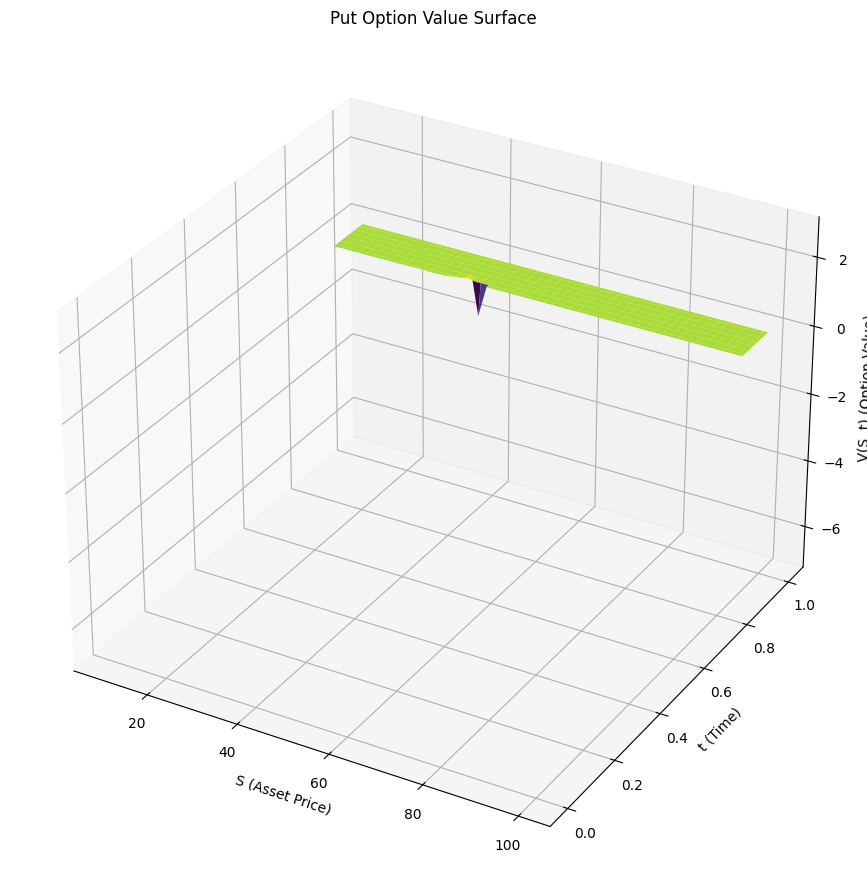

In [1016]:
S_vals = np.linspace(10, 100, 100)
t_vals = np.linspace(0, T, 100)
S_grid, t_grid = np.meshgrid(S_vals, t_vals)
V_func = np.vectorize(V)
V_grid = V_func(S_grid, t_grid)

fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S_grid, t_grid, V_grid, cmap='viridis')
ax.set_xlabel('S (Asset Price)')
ax.set_ylabel('t (Time)')
ax.set_zlabel('V(S, t) (Option Value)')
ax.set_title(f"{option_type.capitalize()} Option Value Surface")
plt.tight_layout()
plt.show()

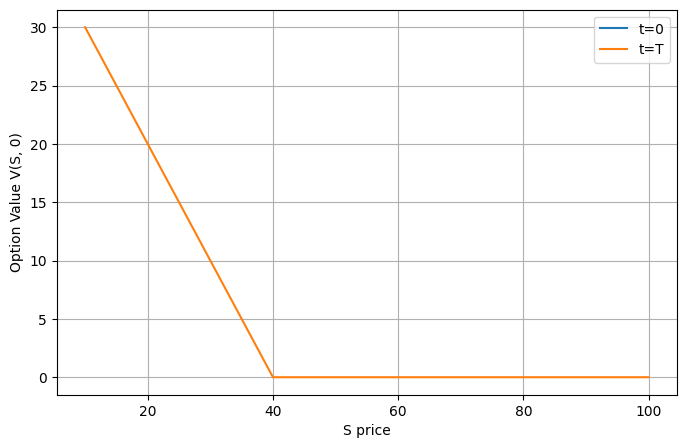

In [1017]:
plt.figure(figsize=(8, 5))
plt.plot(S_vals, V_grid[0,:], label="t=0")
plt.plot(S_vals, V_grid[-1,:], label="t=T")
plt.xlabel("S price")
plt.ylabel("Option Value V(S, 0)")
plt.legend()
plt.grid(True)
plt.show()

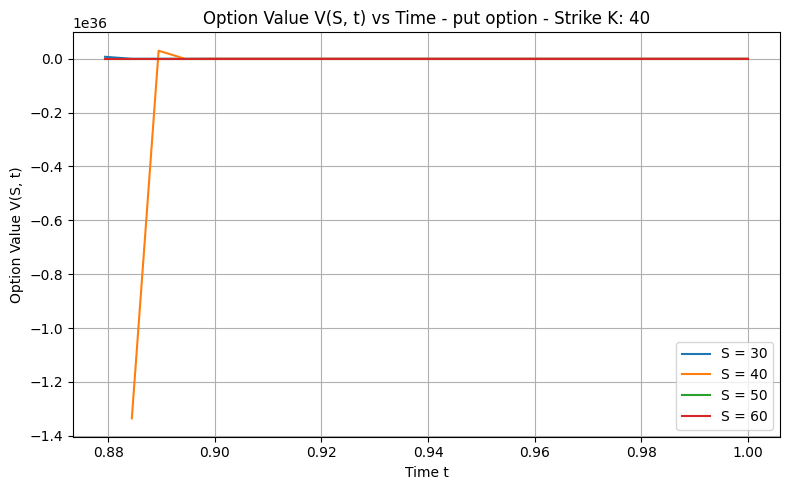

In [1018]:
def plot_V_over_time(S_list):
    t_vals = np.linspace(0, T, 200)
    plt.figure(figsize=(8, 5))
    for S in S_list:
        values = [V(S, t) for t in t_vals]
        plt.plot(t_vals, values, label=f"S = {S}")
    plt.title(f"Option Value V(S, t) vs Time - {option_type} option - Strike K: {K}")
    plt.xlabel("Time t")
    plt.ylabel("Option Value V(S, t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_V_over_time([30, 40, 50, 60])
